In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import scienceplots
plt.style.use(['science', 'no-latex'])

from FastBEMT import BEMT, Environment, F1A, Plotter, Propeller, Simulation
from FastBEMT.Aeroacoustics import circular_observer_array, uniform_observer_grid
from FastBEMT.Utils.DataLoader import load_propeller_dict

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch device: {DEVICE}")

PyTorch device: cuda


In [5]:
RPM = 7000.0
VPM_LAST_ROTATIONS = 10
MAP_DOMAIN_SIZE = 5.0
MAP_GRID_SIZE = 30
OBSERVER_BATCH_SIZE = 50
MAP_METRIC = "ospl"  # Use "oaspl" for the A-weighted map.
VPM_DATA_DIR = Path("../Data/VPM")
LOADINGS_PATH = VPM_DATA_DIR / "loadings_TBS3_N_per_m.pt"
CONVERGENCE_PATH = VPM_DATA_DIR / "APC10x7E_high_convergence.csv"
SECTION_GEOMETRY_PATH = VPM_DATA_DIR / "APC10x7E_higher_rotor_sections.csv"
PROPELLER_GEOMETRY_PATH = "../Data/10x7E"


vpm_source_times_all = pd.read_csv(CONVERGENCE_PATH)["T"].to_numpy(dtype=float)

propeller_name, geometry = load_propeller_dict(PROPELLER_GEOMETRY_PATH)[0]

environment = Environment(
    a_inf=343.0,
    rho=1.225,
    mu=1.81e-5,
    p_ref=20.0e-6,
)
simulation = Simulation(
    revolutions=1,
    timesteps_per_revolution=1,
    device=DEVICE,
)
propeller = Propeller(geometry, environment, simulation)
f1a = F1A(
    propeller=propeller,
    loadings=LOADINGS_PATH,
    rpm=RPM,
    source_times=CONVERGENCE_PATH,
    last_rotations=VPM_LAST_ROTATIONS,
    loading_geometry=SECTION_GEOMETRY_PATH,
)
vpm_window_label = (
    "all available rotations"
    if VPM_LAST_ROTATIONS is None
    else f"last {VPM_LAST_ROTATIONS:g} rotations"
)
vpm_source_times = f1a.kinematics.source_times.detach().cpu().numpy()
np.testing.assert_allclose(
    simulation.src_times.detach().cpu().numpy(),
    vpm_source_times,
)
print(
    f"Loaded F1A loadings: {tuple(f1a.loads.shape)} N/m "
    f"with {f1a.nt} of {vpm_source_times_all.size} source timestamps "
    f"({vpm_window_label})"
)

Loaded F1A loadings: (1801, 2, 50, 3) N/m with 1801 of 1937 source timestamps (last 10 rotations)


In [6]:
map_observers = uniform_observer_grid(
    size=MAP_DOMAIN_SIZE,
    nx=MAP_GRID_SIZE,
    ny=MAP_GRID_SIZE,
)
f1a.run(
    observers=map_observers,
    observer_time_range=simulation.observer_time_range,
    num_observer_times=simulation.num_obs_times,
    observer_batch_size=OBSERVER_BATCH_SIZE,
)

map_ospl = f1a.ospl.cpu().numpy()
map_oaspl = f1a.oaspl.cpu().numpy()
map_level = map_oaspl if MAP_METRIC == "oaspl" else map_ospl
map_units = "dB(A)" if MAP_METRIC == "oaspl" else "dB"

print(f"F1A pressure shape: {tuple(f1a.p_tot.shape)}")
print(
    f"F1A map {MAP_METRIC.upper()} range: "
    f"{np.nanmin(map_level):.2f} to {np.nanmax(map_level):.2f} {map_units}"
)

F1A pressure shape: (900, 1620)
F1A map OSPL range: 48.57 to 98.11 dB


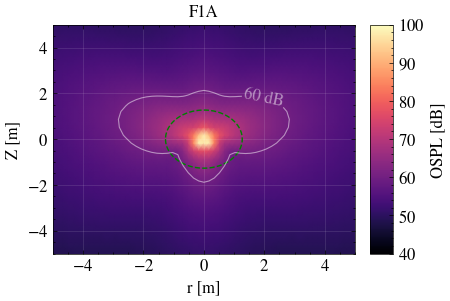

In [7]:
plotter = Plotter(propeller)
plotter.plot_acoustic_map(
    grid_size=MAP_GRID_SIZE,
    domain_size=MAP_DOMAIN_SIZE,
    noise_type="f1a",
    metric=MAP_METRIC,
    levels=map_level,
    figsize=(4.5, 3.0),
    cmap="magma",
    contour_levels=[60],
    mirror=True,
)

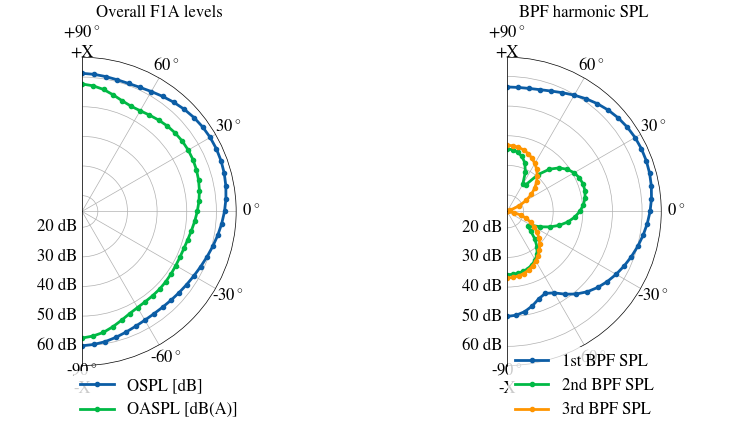

In [8]:
POLAR_RADIUS = 1.88
POLAR_OBSERVERS = 37
elevation_deg = np.linspace(-90.0, 90.0, POLAR_OBSERVERS)
polar_observers = circular_observer_array(
    radius=POLAR_RADIUS,
    n_points=POLAR_OBSERVERS,
)

f1a.run(
    observers=polar_observers,
    observer_time_range=simulation.observer_time_range,
    num_observer_times=simulation.num_obs_times,
)

polar_ospl = f1a.ospl.cpu().numpy()
polar_oaspl = f1a.oaspl.cpu().numpy()
polar_frequency = f1a.frequencies.cpu().numpy()
polar_spl = f1a.spl.cpu().numpy()

blade_passing_frequency = RPM * propeller.n_blades / 60.0
bpf_orders = np.array([1.0, 2.0, 3.0])
bpf_indices = np.array(
    [
        int(np.argmin(np.abs(polar_frequency - order * blade_passing_frequency)))
        for order in bpf_orders
    ]
)
bpf_spl = polar_spl[:, bpf_indices]

overall_curves = {
    "OSPL [dB]": polar_ospl,
    "OASPL [dB(A)]": polar_oaspl,
}
bpf_curves = {
    "1st BPF SPL": bpf_spl[:, 0],
    "2nd BPF SPL": bpf_spl[:, 1],
    "3rd BPF SPL": bpf_spl[:, 2],
}
theta = np.deg2rad(elevation_deg)


def plot_level_polar(axis, curves, title):
    peak = max(float(np.max(values)) for values in curves.values())
    floor = peak - 50.0

    for label, values in curves.items():
        radius = np.maximum(values, floor) - floor
        axis.plot(
            theta,
            radius,
            linewidth=2.0,
            marker="o",
            markersize=3,
            label=label,
        )

    axis.set_title(title, fontsize=12)
    axis.set_theta_zero_location("E")
    axis.set_theta_direction(1)
    axis.set_thetamin(-90.0)
    axis.set_thetamax(90.0)
    axis.set_xticks(
        np.deg2rad([-90.0, -60.0, -30.0, 0.0, 30.0, 60.0, 90.0])
    )
    axis.set_xticklabels(
        [
            r"-90$^\circ$" + "\n-X",
            r"-60$^\circ$",
            r"-30$^\circ$",
            r"0$^\circ$",
            r"30$^\circ$",
            r"60$^\circ$",
            r"+90$^\circ$" + "\n+X",
        ]
    )
    level_ticks = np.arange(
        np.ceil(floor / 10.0) * 10.0,
        peak + 1.0,
        10.0,
    )
    axis.set_yticks(level_ticks - floor)
    axis.set_yticklabels([f"{level:.0f} dB" for level in level_ticks])
    axis.tick_params(axis="both", labelsize=12)
    axis.set_ylim(0.0, peak + 2.0 - floor)
    axis.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, -0.22),
        ncol=1,
        frameon=True,
        edgecolor="none",
        fontsize=12,
    )


figure, polar_axes = plt.subplots(
    1,
    2,
    figsize=(8.5, 4.4),
    subplot_kw={"projection": "polar"},
    constrained_layout=True,
)
plot_level_polar(polar_axes[0], overall_curves, "Overall F1A levels")
plot_level_polar(polar_axes[1], bpf_curves, "BPF harmonic SPL")
plt.show()

c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\neuralfoil\main.py:171: RuntimeWarning: divide by zero encountered in log
  (np.log(Re) - 12.5) / 3.5,
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\aerosandbox\numpy\surrogate_model_tools.py:253: RuntimeWarning: invalid value encountered in divide
  return x / (1 + _np.exp(-beta * x))
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\neuralfoil\main.py:227: RuntimeWarning: invalid value encountered in matmul
  x = w @ x + np.reshape(b, (-1, 1))
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\aerosandbox\library\aerodynamics\viscous.py:142: RuntimeWarning: divide by zero encountered in scalar divide
  return 0.074 / Re_L ** (1 / 5)
C:\Users\PusinoDavide\FastBEMT\src\FastBEMT\Aerodynamics\Section.py:156: RuntimeWarning

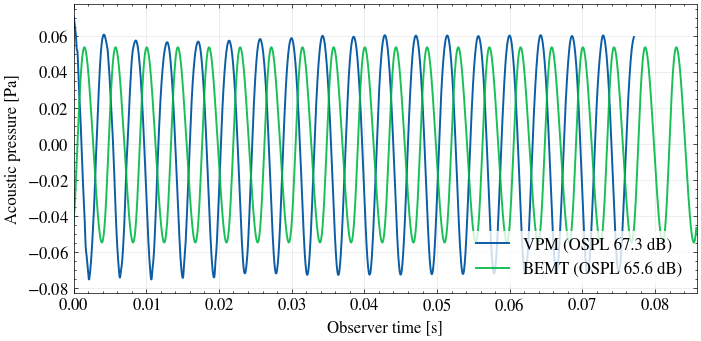

Observer position: [0.   0.   1.88] m
Samples per rotation: 180
Compared rotations: 10


In [10]:
PRESSURE_OBSERVER_RADIUS = 1.88
PRESSURE_ROTATIONS = (
    10
    if VPM_LAST_ROTATIONS is None
    else max(1, int(np.floor(VPM_LAST_ROTATIONS)))
)
BEMT_GEOMETRY_PATH = "../Data/10x7E"

pressure_observer = np.array(
    [[0.0, 0.0, PRESSURE_OBSERVER_RADIUS]],
    dtype=np.float32,
)
pressure_rotation_period = 60.0 / RPM
pressure_dt = float(np.median(np.diff(vpm_source_times)))
pressure_samples_per_rotation = int(
    round(pressure_rotation_period / pressure_dt)
)
pressure_rotations = min(
    PRESSURE_ROTATIONS,
    int(
        np.floor(
            (vpm_source_times[-1] - vpm_source_times[0])
            / pressure_rotation_period
        )
    ),
)
pressure_time_range = pressure_rotations * pressure_rotation_period
pressure_samples = pressure_rotations * pressure_samples_per_rotation

f1a.run(
    observers=pressure_observer,
    observer_time_range=pressure_time_range,
    num_observer_times=pressure_samples,
)
loadings_time = f1a.t[0].detach().cpu().numpy()
loadings_pressure = f1a.p_tot[0].detach().cpu().numpy()
vpm_ospl = float(f1a.ospl[0].detach().cpu())

_, bemt_geometry = load_propeller_dict(BEMT_GEOMETRY_PATH)[0]

bemt_simulation = Simulation(
    revolutions=pressure_rotations + 2,
    timesteps_per_revolution=pressure_samples_per_rotation,
    device=DEVICE,
)
bemt_propeller = Propeller(
    bemt_geometry,
    environment,
    bemt_simulation,
)
bemt = BEMT(
    propeller=bemt_propeller,
    environment=environment,
    rpm=RPM,
    v_inf=0.0,
)
bemt_f1a = F1A(
    propeller=bemt_propeller,
    bemt=bemt,
)
bemt_f1a.run(
    observers=pressure_observer,
    observer_time_range=pressure_time_range,
    num_observer_times=pressure_samples,
)
bemt_time = bemt_f1a.t[0].detach().cpu().numpy()
bemt_pressure = bemt_f1a.p_tot[0].detach().cpu().numpy()
bemt_ospl = float(bemt_f1a.ospl[0].detach().cpu())
vpm_label = f"VPM (OSPL {vpm_ospl:.1f} dB)"
bemt_label = f"BEMT (OSPL {bemt_ospl:.1f} dB)"

figure, axis = plt.subplots(figsize=(7.0, 3.4), constrained_layout=True)
axis.plot(
    loadings_time - loadings_time[0],
    loadings_pressure,
    linewidth=1.4,
    label=vpm_label,
)
axis.plot(
    bemt_time - bemt_time[0],
    bemt_pressure,
    linewidth=1.4,
    alpha=0.9,
    label=bemt_label,
)
axis.set_xlabel("Observer time [s]", fontsize=12)
axis.set_ylabel("Acoustic pressure [Pa]", fontsize=12)
axis.set_xlim(0.0, pressure_time_range)
axis.tick_params(axis="both", labelsize=12)
axis.grid(True, alpha=0.3)
axis.legend(frameon=True, edgecolor="none", fontsize=12, loc='lower right')
plt.show()

print(f"Observer position: {pressure_observer[0]} m")
print(f"Samples per rotation: {pressure_samples_per_rotation}")
print(f"Compared rotations: {pressure_rotations}")

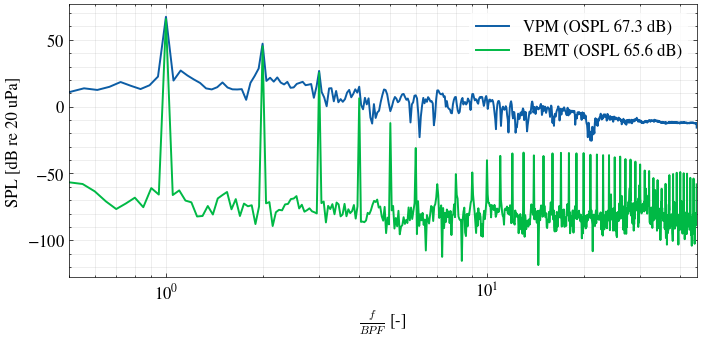

In [11]:
vpm_frequency = f1a.frequencies.detach().cpu().numpy()
vpm_spl = f1a.spl[0].detach().cpu().numpy()
bemt_frequency = bemt_f1a.frequencies.detach().cpu().numpy()
bemt_spl = bemt_f1a.spl[0].detach().cpu().numpy()

figure, axis = plt.subplots(figsize=(7.0, 3.4), constrained_layout=True)
for frequency, spl, label in (
    (vpm_frequency, vpm_spl, vpm_label),
    (bemt_frequency, bemt_spl, bemt_label),
):
    positive_frequency = frequency > 0.0
    axis.semilogx(
        frequency[positive_frequency]/blade_passing_frequency,
        spl[positive_frequency],
        linewidth=1.4,
        label=label,
    )
axis.set_xlim(0.5, 45)
axis.set_xlabel(r"$\frac{f}{BPF}$ [-]", fontsize=12)
axis.set_ylabel("SPL [dB re 20 uPa]", fontsize=12)
axis.tick_params(axis="both", labelsize=12)
axis.grid(True, which="both", alpha=0.3)
axis.legend(frameon=True, edgecolor="none", fontsize=12)
plt.show()

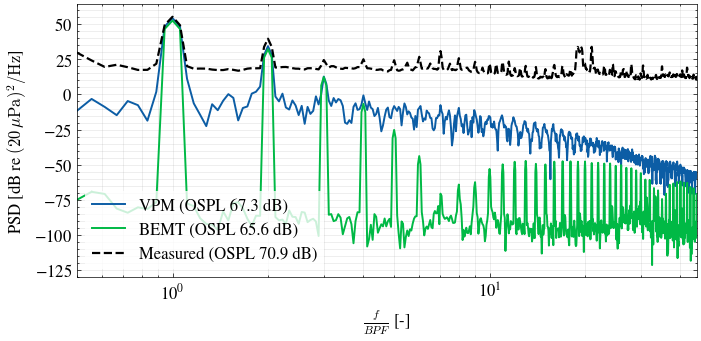

In [31]:
from scipy.signal import welch
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

p_ref = 20e-6  # Pa

fs_vpm = 1.0 / np.median(np.diff(loadings_time))
fs_bemt = 1.0 / np.median(np.diff(bemt_time))

nperseg = min(4096, len(loadings_pressure), len(bemt_pressure))
noverlap = nperseg // 2

# Load measured pressure
measured_path = Path("../10x7E_00_actual.pkl")
measured_data = pickle.load(measured_path.open("rb"))[10]
measured_pressure = np.asarray(measured_data["scaled_samples"], dtype=float)
measured_sample_rate = float(measured_data["sample_rate"])
measured_ospl = 20.0 * np.log10(
    np.sqrt(np.mean(measured_pressure ** 2)) / (20.0e-6)
)
measured_label = f"Measured (OSPL {measured_ospl:.1f} dB)"

figure, axis = plt.subplots(figsize=(7.0, 3.4), constrained_layout=True)

for pressure, fs, label in (
    (loadings_pressure, fs_vpm, vpm_label),
    (bemt_pressure, fs_bemt, bemt_label),
):
    pressure_fluct = pressure - np.mean(pressure)

    frequency, psd = welch(
        pressure_fluct,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend="constant",
        scaling="density",  # Pa^2 / Hz
    )

    positive_frequency = frequency > 0.0
    psd_db = 10.0 * np.log10(psd / p_ref**2)

    axis.semilogx(
        frequency[positive_frequency] / blade_passing_frequency,
        psd_db[positive_frequency],
        linewidth=1.4,
        label=label,
    )

# Add measured PSD
measured_pressure_fluct = measured_pressure - np.mean(measured_pressure)
measured_frequency, measured_psd = welch(
    measured_pressure_fluct,
    fs=measured_sample_rate,
    window="hann",
    nperseg=5055,
    noverlap=noverlap,
    detrend="constant",
    scaling="density",  # Pa^2 / Hz
)
measured_positive_frequency = measured_frequency > 0.0
measured_psd_db = 10.0 * np.log10(measured_psd / p_ref**2)

axis.semilogx(
    measured_frequency[measured_positive_frequency] / blade_passing_frequency,
    measured_psd_db[measured_positive_frequency],
    linewidth=1.6,
    linestyle="--",
    color="black",
    label=measured_label,
)

axis.set_xlim(0.5, 45)
axis.set_xlabel(r"$\frac{f}{BPF}$ [-]", fontsize=12)
axis.set_ylabel(r"PSD [dB re $(20\,\mu\mathrm{Pa})^2/\mathrm{Hz}$]", fontsize=12)
axis.tick_params(axis="both", labelsize=12)
axis.grid(True, which="both", alpha=0.3)
axis.legend(frameon=True, edgecolor="none", fontsize=12, loc='lower left')
plt.show()